# Inspect BDD100K annotations with OpenCV
Run the cells in order using the **Lannet310** environment (OpenCV, NumPy and IPython).
`class_in_files` maps each category to **unique JSON paths**. Select a category and index below to see its matching image and annotations.

These are dataset annotations, not model predictions. `lane/crosswalk` identifies pedestrian-crossing markings; `lane/double yellow` identifies double-yellow road markings. The viewer shows the original labels, including their direction/style; it does not apply the training loader's filters.

In [1]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import numpy as np
from IPython.display import Image as NotebookImage, display

json_folder = Path("/Users/amannindra/Projects/Auto/100k_json")
image_folder = Path("/Users/amannindra/Projects/Auto/100k_images")
split = "train"  # "train", "val", or "test"
json_train, json_val, json_test = [json_folder / s for s in ("train", "val", "test")]
image_train, image_val, image_test = [image_folder / s for s in ("train", "val", "test")]
json_files = sorted((json_folder / split).glob("*.json"))
if not json_files or not (image_folder / split).is_dir():
    raise FileNotFoundError(f"Missing images or JSON files for split {split!r}")
print(f"{split}: {len(json_files):,} JSON files")

train: 70,000 JSON files


In [2]:
all_categories = Counter()  # number of annotated objects, not images
files_by_class = defaultdict(list)
for number, json_path in enumerate(json_files, 1):
    with json_path.open() as handle:
        annotation = json.load(handle)
    categories_in_image = set()
    for frame in annotation.get("frames", []):
        for obj in frame.get("objects", []):
            category = obj["category"]
            all_categories[category] += 1
            categories_in_image.add(category)
    for category in sorted(categories_in_image):
        files_by_class[category].append(str(json_path))
    if number % 10000 == 0:
        print(f"Indexed {number:,}/{len(json_files):,} files")
class_in_files = dict(files_by_class)
for category in sorted(class_in_files):
    if category.startswith("lane/"):
        print(f"{category:22} {len(class_in_files[category]):6,} images | {all_categories[category]:7,} objects")

Indexed 10,000/70,000 files
Indexed 20,000/70,000 files
Indexed 30,000/70,000 files
Indexed 40,000/70,000 files
Indexed 50,000/70,000 files
Indexed 60,000/70,000 files
Indexed 70,000/70,000 files
lane/crosswalk         25,637 images | 108,284 objects
lane/double other          13 images |      26 objects
lane/double white       2,501 images |   5,674 objects
lane/double yellow     15,233 images |  37,519 objects
lane/road curb         56,059 images | 109,868 objects
lane/single other          94 images |     249 objects
lane/single white      51,842 images | 247,108 objects
lane/single yellow     10,020 images |  20,220 objects


## Drawing helpers
OpenCV loads and draws in BGR. PNG encoding displays the colors correctly inline in Jupyter; no `cv2.imshow()` window is needed.
Cubic Bézier segments are sampled before drawing, rather than connecting their control points as straight lines. Overlay colors are chosen for visibility: crosswalk is magenta, double yellow is yellow.

In [3]:
COLORS_BGR = {
    "lane/crosswalk": (255, 0, 255),
    "lane/double yellow": (0, 255, 255),
    "lane/single yellow": (0, 200, 255),
    "lane/single white": (255, 255, 255),
    "lane/double white": (255, 255, 255),
    "lane/road curb": (0, 255, 0),
}


def polyline_points(vertices):
    """Sample legacy BDD [x, y, outgoing L/C code] paths."""
    result = []
    i = 0
    while i < len(vertices) - 1:
        if vertices[i][2] == "C":
            if i + 3 >= len(vertices) or any(v[2] != "C" for v in vertices[i:i+3]):
                raise ValueError("Malformed cubic segment in BDD poly2d")
            p = np.array([v[:2] for v in vertices[i:i+4]], dtype=float)
            t = np.linspace(0, 1, 65)[:, None]
            segment = (1-t)**3*p[0] + 3*(1-t)**2*t*p[1] + 3*(1-t)*t**2*p[2] + t**3*p[3]
            i += 3
        elif vertices[i][2] == "L":
            segment = np.array([v[:2] for v in vertices[i:i+2]], dtype=float)
            i += 1
        else:
            raise ValueError(f"Unknown poly2d code: {vertices[i][2]}")
        result.extend(segment)
    return np.rint(result).astype(np.int32).reshape(-1, 1, 2)


def load_pair(json_path):
    json_path = Path(json_path)
    with json_path.open() as handle:
        annotation = json.load(handle)
    image_name = Path(annotation.get("name", json_path.stem)).stem + ".jpg"
    image_path = image_folder / json_path.parent.name / image_name
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(f"Could not decode {image_path}")
    objects = [obj for frame in annotation.get("frames", []) for obj in frame.get("objects", [])]
    return image, objects, image_path


def overlay_class(image, objects, category):
    canvas = image.copy()
    selected = [obj for obj in objects if obj.get("category") == category]
    color = COLORS_BGR.get(category, (255, 180, 0))
    for obj in selected:
        if "poly2d" in obj:
            points = polyline_points(obj["poly2d"])
            if len(points) < 2:
                continue
            closed = category.startswith("area/")
            cv2.polylines(canvas, [points], closed, (0, 0, 0), 7, cv2.LINE_AA)
            cv2.polylines(canvas, [points], closed, color, 3, cv2.LINE_AA)
            x, y = points[len(points)//2, 0]
        elif "box2d" in obj:
            box = obj["box2d"]
            x, y = int(box["x1"]), int(box["y1"])
            cv2.rectangle(canvas, (x, y), (int(box["x2"]), int(box["y2"])), color, 3)
        else:
            continue
        position = (int(np.clip(x, 0, canvas.shape[1]-70)), int(np.clip(y-8, 20, canvas.shape[0]-5)))
        text = str(obj.get("id", ""))
        cv2.putText(canvas, text, position, cv2.FONT_HERSHEY_SIMPLEX, .65, (0, 0, 0), 4, cv2.LINE_AA)
        cv2.putText(canvas, text, position, cv2.FONT_HERSHEY_SIMPLEX, .65, color, 2, cv2.LINE_AA)
    return canvas, selected


def panel(image, title):
    canvas = cv2.copyMakeBorder(image, 55, 0, 0, 0, cv2.BORDER_CONSTANT, value=(25, 25, 25))
    cv2.putText(canvas, title, (16, 36), cv2.FONT_HERSHEY_SIMPLEX, .85, (255, 255, 255), 2, cv2.LINE_AA)
    return canvas


def display_bgr(image, width=1400):
    ok, encoded = cv2.imencode(".png", image)
    if not ok:
        raise RuntimeError("OpenCV could not encode the notebook display")
    display(NotebookImage(data=encoded.tobytes(), width=width))


def show_annotation(category, sample_index=0):
    paths = class_in_files.get(category, [])
    if not paths:
        raise ValueError(f"No images indexed for {category!r}. Run the indexing cell first.")
    if not 0 <= sample_index < len(paths):
        raise IndexError(f"sample_index must be between 0 and {len(paths)-1}")
    image, objects, image_path = load_pair(paths[sample_index])
    overlay, selected = overlay_class(image, objects, category)
    print(f"Image: {image_path}\nJSON: {paths[sample_index]}")
    print(f"{category}: {len(selected)} objects; sample {sample_index}/{len(paths)-1}")
    for obj in selected:
        print(f"  id={obj.get('id')}: {obj.get('attributes', {})}")
    display_bgr(cv2.hconcat([panel(image, "Original image"), panel(overlay, category)]))


def compare_classes(categories=("lane/crosswalk", "lane/double yellow"), sample_index=0):
    """Compare annotations on the SAME image, selected from dictionary intersection."""
    if len(categories) != 2:
        raise ValueError("Choose exactly two categories")
    common_files = sorted(set(class_in_files.get(categories[0], [])) & set(class_in_files.get(categories[1], [])))
    if not common_files:
        raise ValueError("No shared image. Use show_annotation() separately for each class.")
    if not 0 <= sample_index < len(common_files):
        raise IndexError(f"sample_index must be between 0 and {len(common_files)-1}")
    image, objects, image_path = load_pair(common_files[sample_index])
    print(f"{len(common_files):,} images contain both classes. Showing {sample_index}: {image_path.name}")
    print(f"JSON: {common_files[sample_index]}")
    panels = []
    for category in categories:
        overlay, selected = overlay_class(image, objects, category)
        panels.append(panel(overlay, f"{category} ({len(selected)} objects)"))
        print(category, [(obj.get("id"), obj.get("attributes", {})) for obj in selected])
    display_bgr(cv2.hconcat(panels))

## Choose a class and image
Change `category` and `sample_index`, then rerun just the next cell. Object IDs drawn on the image correspond to the printed attributes.

Image: /Users/amannindra/Projects/Auto/100k_images/train/000d35d3-41990aa4.jpg
JSON: /Users/amannindra/Projects/Auto/100k_json/train/000d35d3-41990aa4.json
lane/crosswalk: 3 objects; sample 2/25636
  id=43: {'direction': 'vertical', 'style': 'dashed'}
  id=44: {'direction': 'vertical', 'style': 'dashed'}
  id=45: {'direction': 'vertical', 'style': 'dashed'}


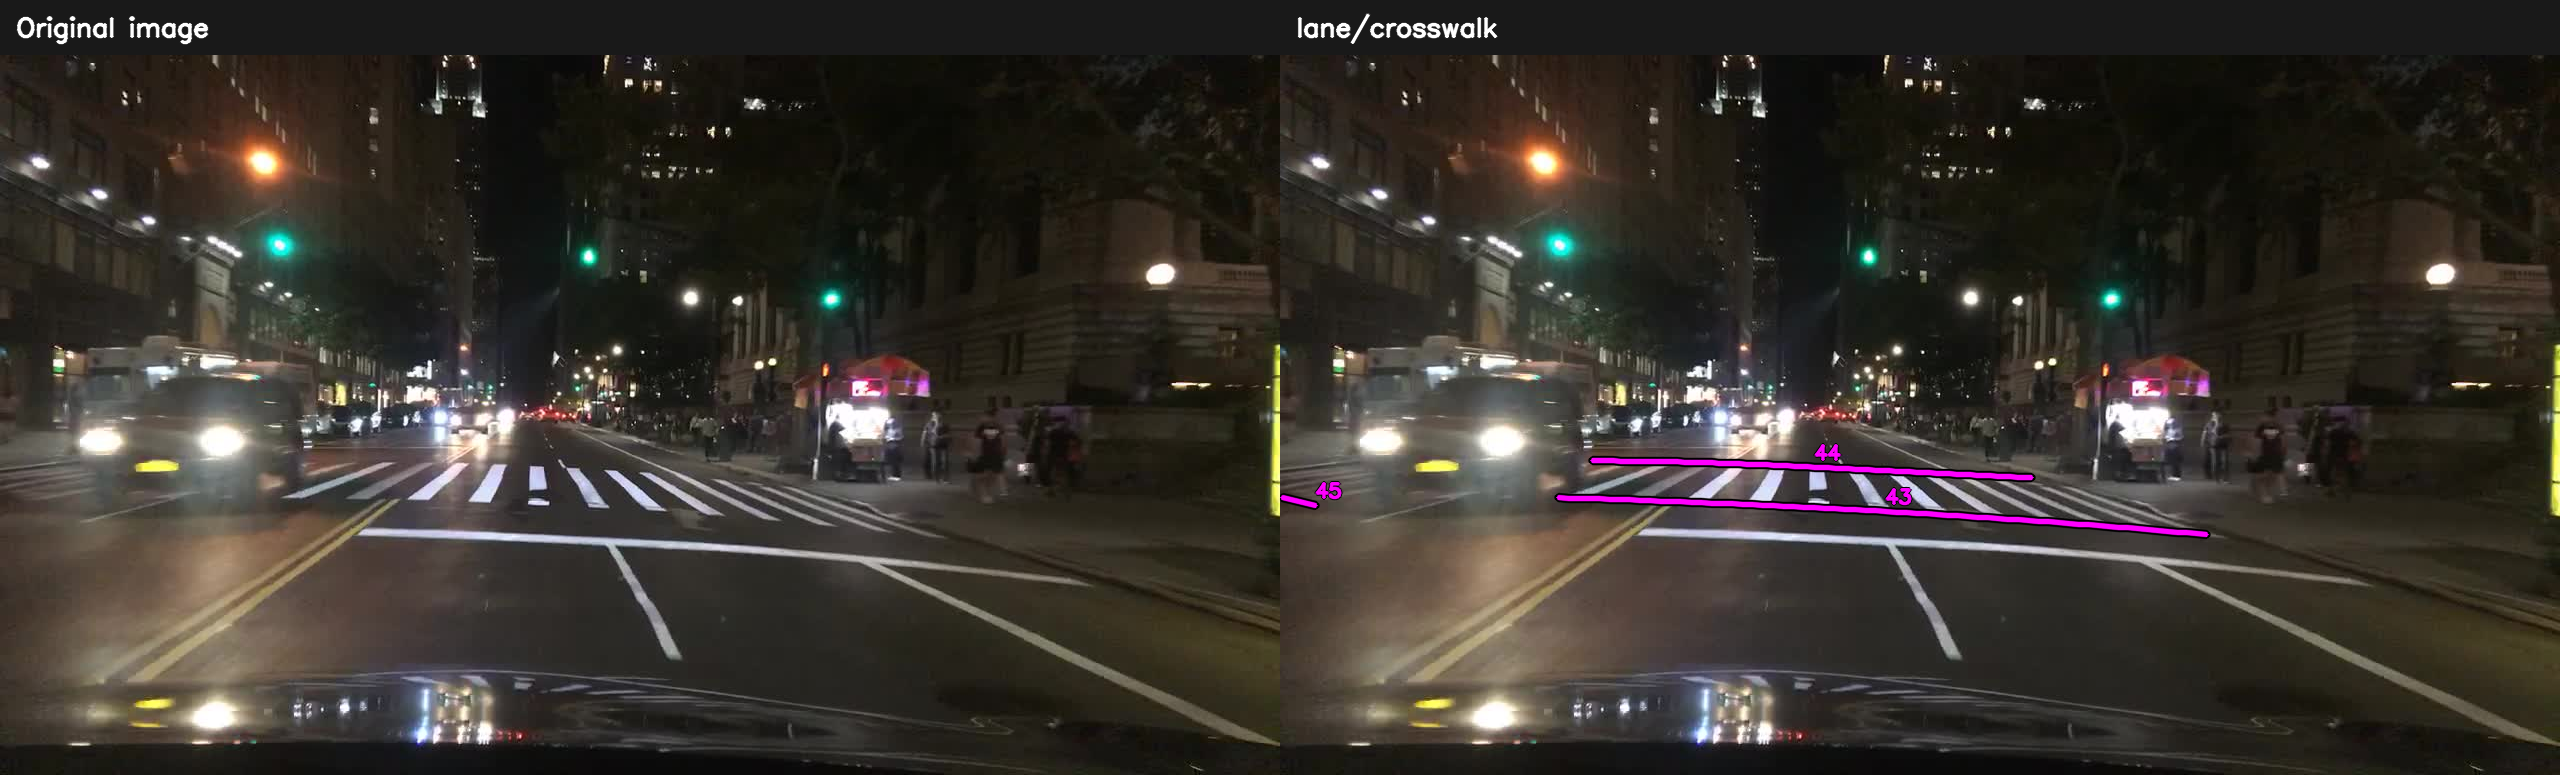

In [6]:
category = "lane/crosswalk"
sample_index = 2
show_annotation(category, sample_index)

## Compare crosswalk and double yellow on the same photograph
Change the index to browse other images containing both classes. Each panel draws **only** its named category; the underlying image is identical.

10,020 images contain both classes. Showing 0: 00067cfb-5adfaaa7.jpg
JSON: /Users/amannindra/Projects/Auto/100k_json/train/00067cfb-5adfaaa7.json
lane/single yellow [(19, {'direction': 'parallel', 'style': 'solid'}), (20, {'direction': 'parallel', 'style': 'solid'})]
lane/single yellow [(19, {'direction': 'parallel', 'style': 'solid'}), (20, {'direction': 'parallel', 'style': 'solid'})]


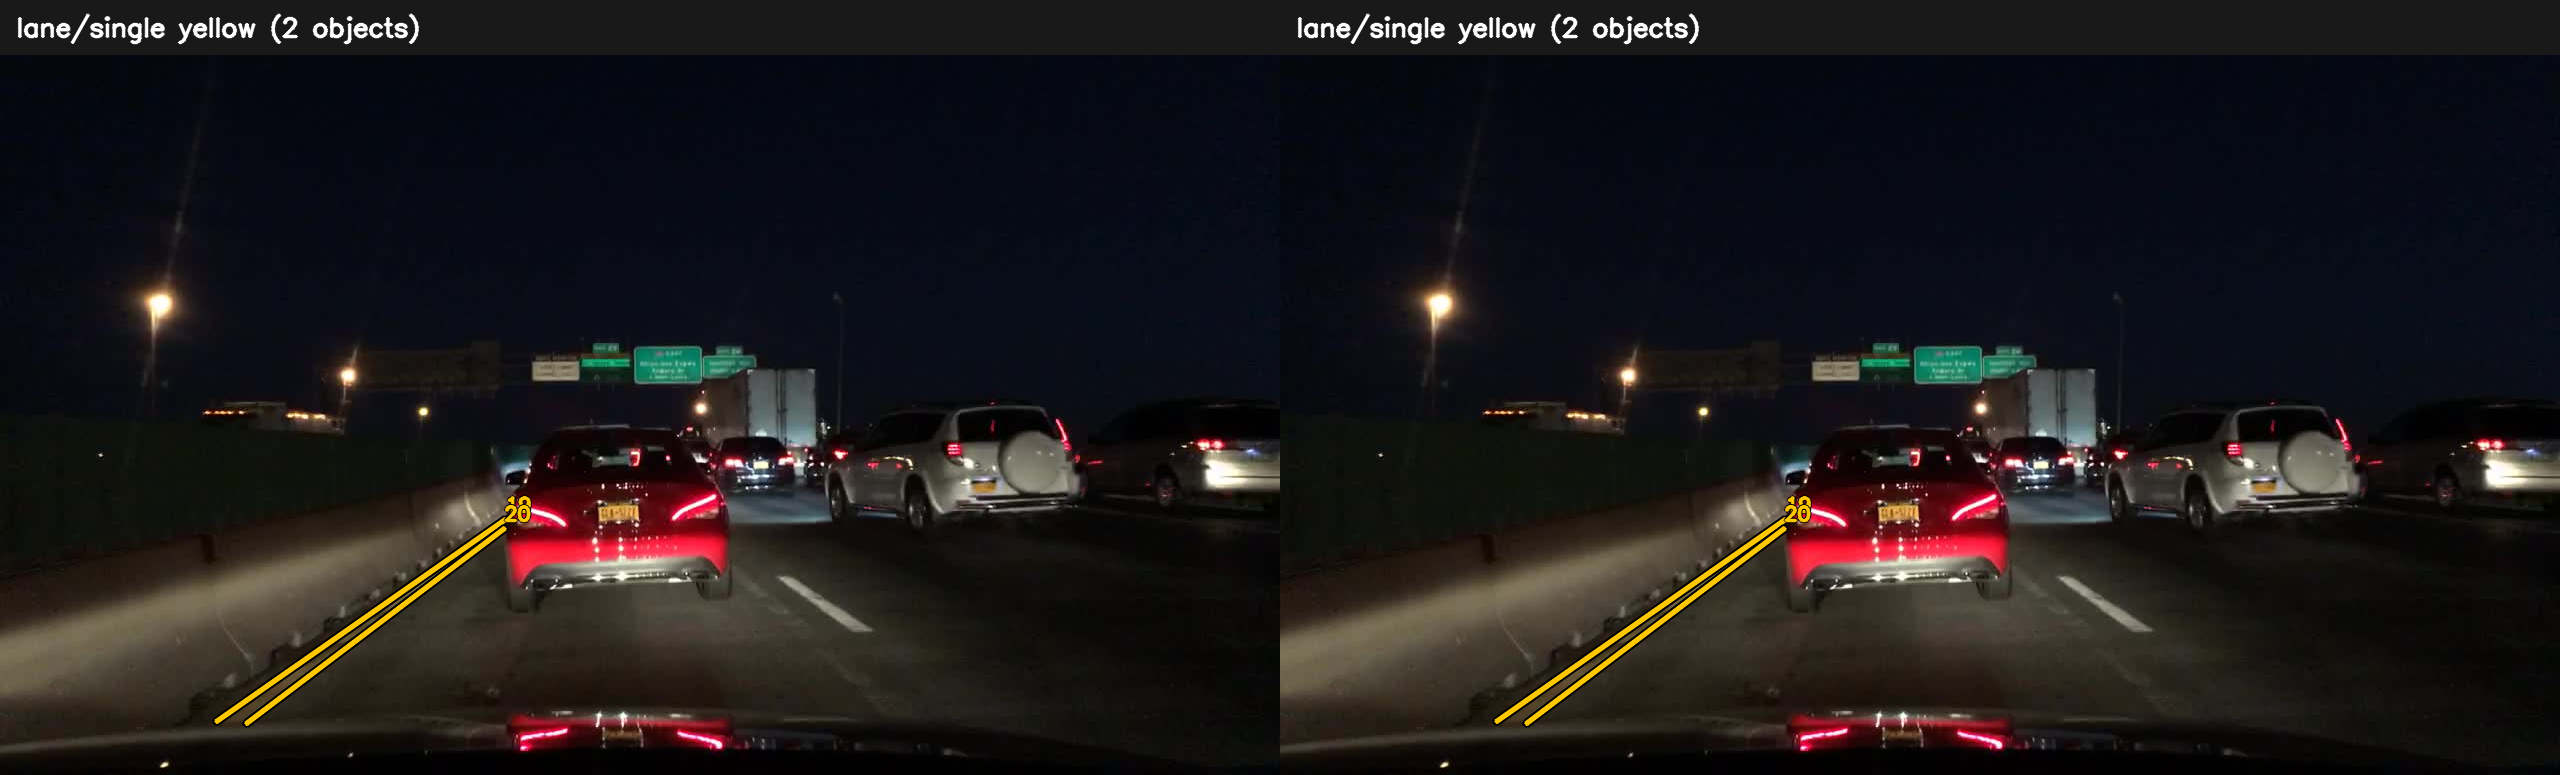

In [15]:
compare_classes(("lane/single yellow","lane/single yellow"), sample_index=0)